<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Soil-Kriging-Analysis/blob/main/kriging_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Library

In [14]:
!pip install pykrige
!pip install geopandas

Import Library

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pykrige.ok import OrdinaryKriging

import warnings
warnings.filterwarnings('ignore')

Data

In [17]:
from google.colab import files

uploaded = files.upload()

Saving soil.xlsx to soil.xlsx


In [18]:
df = pd.read_excel("soil.xlsx")

df.head()

,x,y,lead,zinc
0,181072,333611,299,1022
1,181025,333558,277,1141
2,181165,333537,199,640
3,181298,333484,116,257
4,181307,333330,117,269


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       155 non-null    int64
 1   y       155 non-null    int64
 2   lead    155 non-null    int64
 3   zinc    155 non-null    int64
dtypes: int64(4)
memory usage: 5.0 KB


Statistik Kandungan Zinc

In [20]:
df['zinc'].describe()

,zinc
count,155.000000
mean,469.716129
std,367.073788
min,113.000000
25%,198.000000
50%,326.000000
75%,674.500000
max,1839.000000


Mengecek Distribusi Zinc

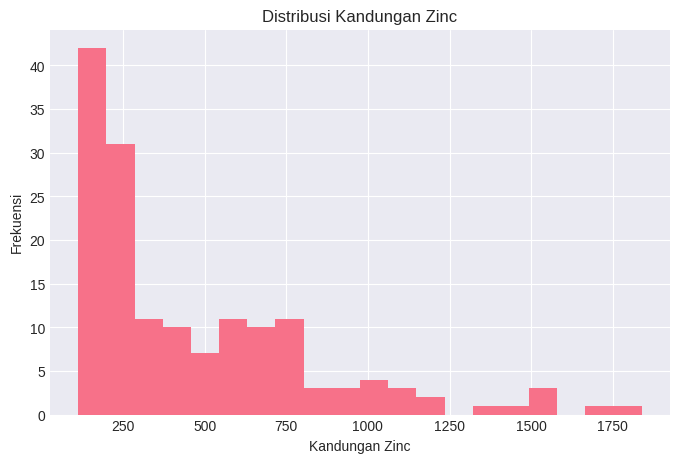

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    df['zinc'],
    bins=20
)

plt.xlabel("Kandungan Zinc")
plt.ylabel("Frekuensi")

plt.title(
    "Distribusi Kandungan Zinc"
)

plt.show()

Persiapan Variabel Spasial

In [32]:
x = df['x'].values
y = df['y'].values
zinc = df['zinc'].values


print("Jumlah titik sampel :", len(zinc))

Jumlah titik sampel : 155


Visualisasi Lokasi Sampel

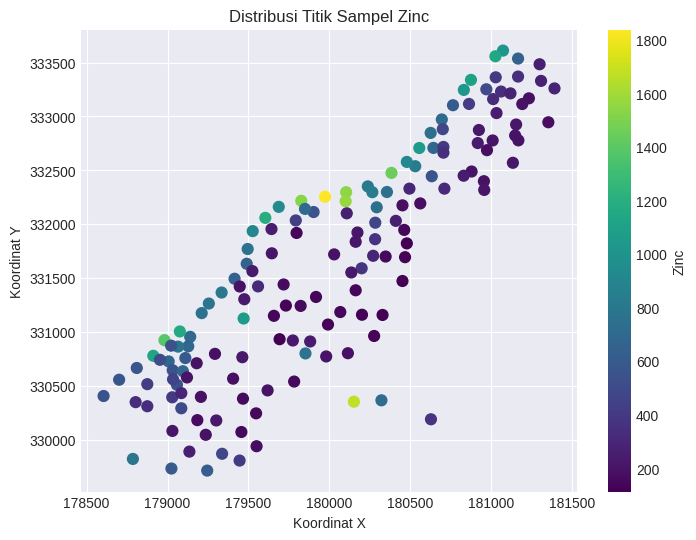

In [33]:
plt.figure(figsize=(8,6))


scatter = plt.scatter(
    x,
    y,
    c=zinc,
    cmap="viridis",
    s=60
)


plt.colorbar(
    scatter,
    label="Zinc"
)


plt.xlabel("Koordinat X")
plt.ylabel("Koordinat Y")


plt.title(
    "Distribusi Titik Sampel Zinc"
)


plt.show()

Membuat Variogram

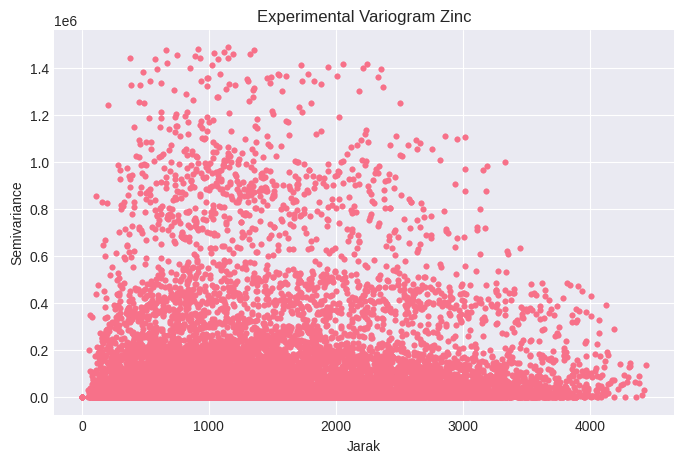

In [34]:
from scipy.spatial.distance import pdist, squareform


coords = np.column_stack(
    (x,y)
)


distance = squareform(
    pdist(coords)
)


gamma = 0.5 * (
    squareform(
        pdist(
            zinc.reshape(-1,1)
        )
    )**2
)


plt.figure(figsize=(8,5))


plt.scatter(
    distance,
    gamma,
    s=10
)


plt.xlabel("Jarak")
plt.ylabel("Semivariance")


plt.title(
    "Experimental Variogram Zinc"
)


plt.show()

Membuat Grid Prediksi

In [35]:
grid_x = np.linspace(
    x.min(),
    x.max(),
    100
)


grid_y = np.linspace(
    y.min(),
    y.max(),
    100
)


print(grid_x.shape)
print(grid_y.shape)

(100,)
(100,)


Ordinary Kriging Model

In [36]:
OK = OrdinaryKriging(

    x,
    y,
    zinc,

    variogram_model='spherical',

    verbose=False,

    enable_plotting=False

)


print("Model Kriging berhasil dibuat")

Model Kriging berhasil dibuat


Prediksi Zinc

In [37]:
z_pred, variance = OK.execute(

    'grid',

    grid_x,

    grid_y

)


print(
    z_pred.shape
)

(100, 100)


Membuat Peta Prediksi Zinc

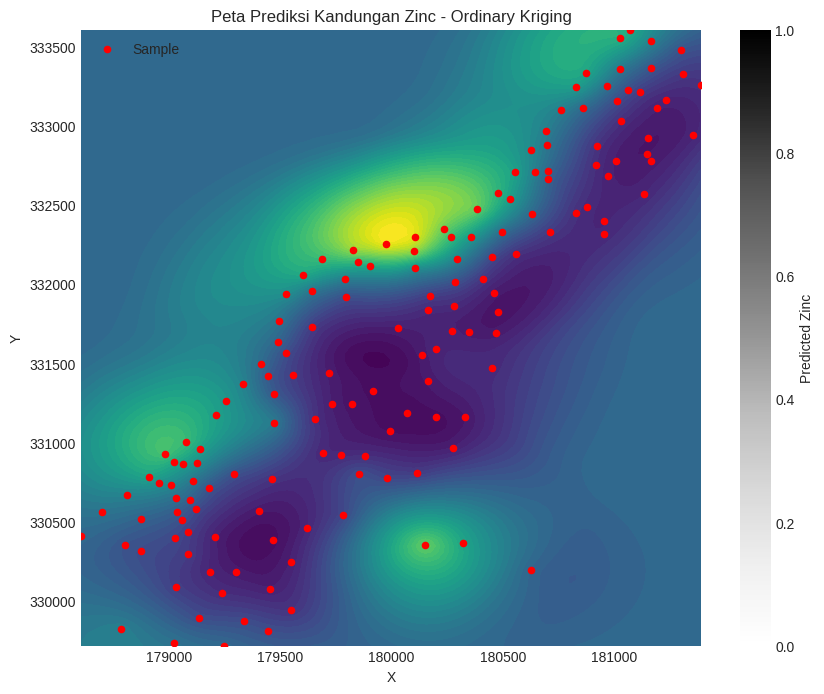

In [38]:
plt.figure(figsize=(10,8))


plt.contourf(

    grid_x,
    grid_y,
    z_pred,

    levels=50,

    cmap='viridis'

)


plt.scatter(

    x,
    y,

    c='red',

    s=20,

    label="Sample"

)


plt.colorbar(
    label="Predicted Zinc"
)


plt.xlabel("X")
plt.ylabel("Y")


plt.title(
    "Peta Prediksi Kandungan Zinc - Ordinary Kriging"
)


plt.legend()


plt.show()

Peta Ketidakpastian

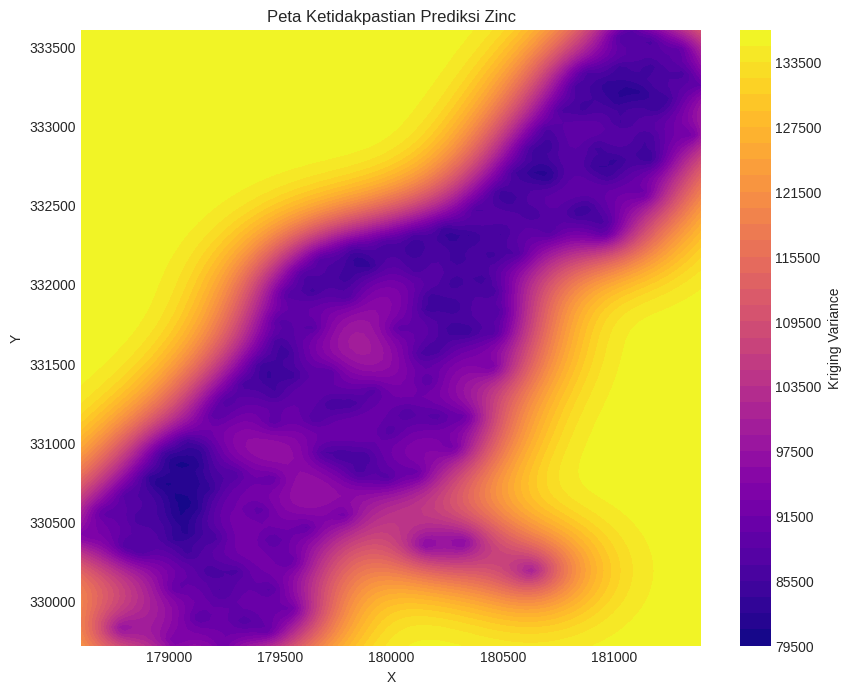

In [39]:
plt.figure(figsize=(10,8))


plt.contourf(

    grid_x,
    grid_y,
    variance,

    levels=50,

    cmap='plasma'

)


plt.colorbar(
    label="Kriging Variance"
)


plt.xlabel("X")
plt.ylabel("Y")


plt.title(
    "Peta Ketidakpastian Prediksi Zinc"
)


plt.show()

Validasi Sederhana

In [42]:
hasil = pd.DataFrame({

    "Zinc_Prediksi":
    z_pred.flatten()

})


hasil.to_excel(
    "hasil_prediksi_zinc.xlsx",
    index=False
)


print(
    "File berhasil disimpan"
)

File berhasil disimpan
